Loading preprocessed dataset...
Extracting Features using Character TF-IDF...

Initializing Model Training...
Training Naive Bayes Model...
Training Support Vector Machine (SVM)...

--- Model Evaluation ---

Naive Bayes Performance:
Accuracy: 0.9700
              precision    recall  f1-score   support

     English       0.92      1.00      0.96       100
      Kikuyu       1.00      0.96      0.98       100
       Sheng       1.00      1.00      1.00       100
     Swahili       0.97      0.92      0.94       100

    accuracy                           0.97       400
   macro avg       0.97      0.97      0.97       400
weighted avg       0.97      0.97      0.97       400


Support Vector Machine Performance:
Accuracy: 0.9800
              precision    recall  f1-score   support

     English       0.93      1.00      0.96       100
      Kikuyu       1.00      1.00      1.00       100
       Sheng       1.00      1.00      1.00       100
     Swahili       1.00      0.92      0.96 

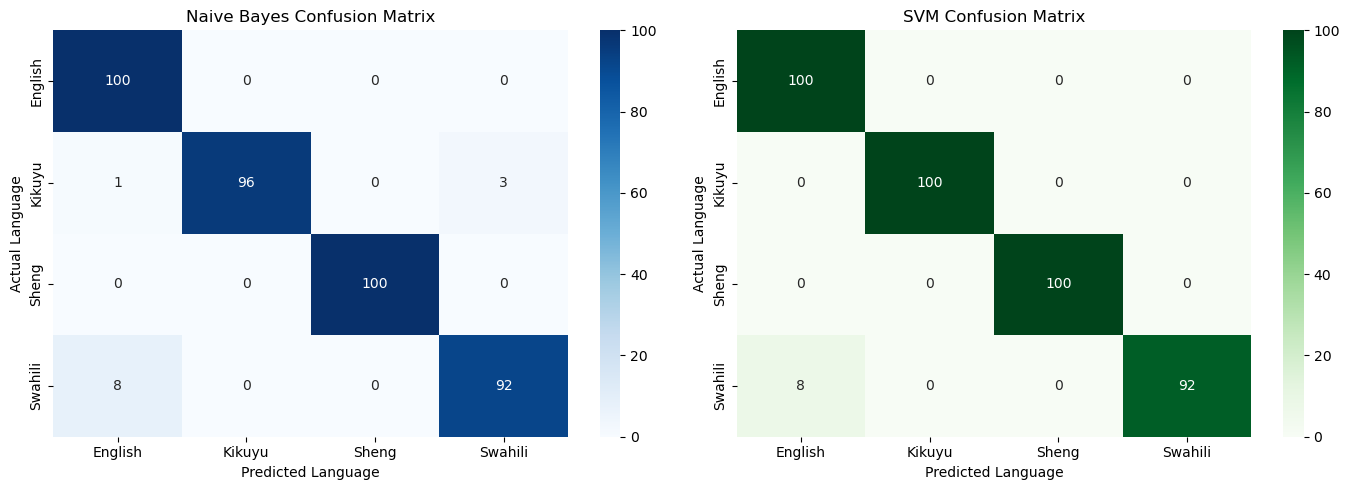


Best model saved as 'language_model_svm.pkl' for final deployment.


In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# STEP 4: FEATURE EXTRACTION (The Bridge)
print("Loading preprocessed dataset...")
df = pd.read_csv('cleaned_master_dataset.csv')
df = df.dropna(subset=['Cleaned_Text'])

X = df['Cleaned_Text']
y = df['Language']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize and train the Vectorizer
print("Extracting Features using Character TF-IDF...")
vectorizer = TfidfVectorizer(analyzer='char', ngram_range=(2, 4), max_features=5000)
X_train_vectorized = vectorizer.fit_transform(X_train)
X_test_vectorized = vectorizer.transform(X_test)

# Save the vectorizer for your final app deployment
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')

# STEP 5 & 6: MODEL TRAINING & EVALUATION
print("\nInitializing Model Training...")

# Train Model A: Multinomial Naive Bayes
print("Training Naive Bayes Model...")
nb_model = MultinomialNB()
nb_model.fit(X_train_vectorized, y_train)

# Train Model B: Support Vector Machine
print("Training Support Vector Machine (SVM)...")
svm_model = LinearSVC(random_state=42)
svm_model.fit(X_train_vectorized, y_train)

print("\n--- Model Evaluation ---")

# Evaluate Naive Bayes
y_pred_nb = nb_model.predict(X_test_vectorized)
print("\nNaive Bayes Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_nb):.4f}")
print(classification_report(y_test, y_pred_nb))

# Evaluate SVM
y_pred_svm = svm_model.predict(X_test_vectorized)
print("\nSupport Vector Machine Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}")
print(classification_report(y_test, y_pred_svm))

# Plot Confusion Matrices
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(confusion_matrix(y_test, y_pred_nb), annot=True, fmt='d', cmap='Blues', 
            xticklabels=svm_model.classes_, yticklabels=svm_model.classes_, ax=ax[0])
ax[0].set_title('Naive Bayes Confusion Matrix')
ax[0].set_ylabel('Actual Language')
ax[0].set_xlabel('Predicted Language')

sns.heatmap(confusion_matrix(y_test, y_pred_svm), annot=True, fmt='d', cmap='Greens', 
            xticklabels=svm_model.classes_, yticklabels=svm_model.classes_, ax=ax[1])
ax[1].set_title('SVM Confusion Matrix')
ax[1].set_ylabel('Actual Language')
ax[1].set_xlabel('Predicted Language')

plt.tight_layout()
plt.show()

# Save the best performing model (SVM) for deployment
joblib.dump(svm_model, 'language_model_svm.pkl')
print("\nBest model saved as 'language_model_svm.pkl' for final deployment.")

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import joblib

print("Training Logistic Regression for Code-Mixing Analysis...")

# 1. Initialize and train the Logistic Regression model
# We set max_iter=1000 to ensure it has enough time to calculate the complex probabilities
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_vectorized, y_train)

# 2. Quick accuracy check to ensure it performs as well as the SVM
y_pred_log = log_model.predict(X_test_vectorized)
print(f"Logistic Regression Accuracy: {accuracy_score(y_test, y_pred_log):.4f}")

# 3. Save the new model for deployment!
joblib.dump(log_model, 'language_model_lr.pkl')
print("\nSuccess! Bonus model saved as 'language_model_lr.pkl'.")

Training Logistic Regression for Code-Mixing Analysis...
Logistic Regression Accuracy: 0.9825

Success! Bonus model saved as 'language_model_lr.pkl'.
